# DIAMOND PREDICTION

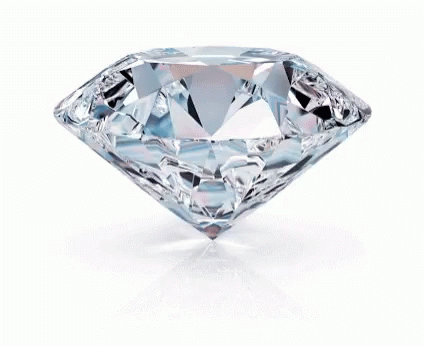

In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load the diamonds dataset
df = sns.load_dataset('diamonds')

df

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [ ]:
df=df.sample(100) # not mandidatory
df

,carat,cut,color,clarity,depth,table,price,x,y,z
7709,1.00,Ideal,J,VS2,61.9,54.0,4278,6.41,6.45,3.98
38507,0.50,Fair,F,SI2,65.5,54.0,1031,5.06,4.92,3.25
46350,0.50,Ideal,E,VS1,61.9,54.1,1759,5.09,5.15,3.17
11073,1.13,Very Good,E,SI1,62.7,57.0,4922,6.62,6.65,4.16
26447,2.50,Ideal,J,SI2,60.7,55.0,15990,8.80,8.66,5.30
...,...,...,...,...,...,...,...,...,...,...
43398,0.64,Fair,I,VS2,55.3,69.0,1411,5.85,5.69,3.19
39151,0.33,Ideal,F,VVS1,62.1,56.0,1062,4.46,4.43,2.76
6058,0.32,Ideal,I,VS2,62.9,57.0,576,4.40,4.37,2.76
47177,0.51,Ideal,F,VS1,62.1,56.0,1836,5.15,5.13,3.19


In [ ]:
# check multicollinarity
nu=df.select_dtypes(include="number")
nu.corr()

,carat,depth,table,price,x,y,z
carat,1.000000,0.016793,0.158465,0.960555,0.974829,0.973604,0.977770
depth,0.016793,1.000000,-0.387840,0.041429,-0.061013,-0.065792,0.070767
table,0.158465,-0.387840,1.000000,0.094764,0.195054,0.185072,0.131047
price,0.960555,0.041429,0.094764,1.000000,0.915329,0.916199,0.924983
x,0.974829,-0.061013,0.195054,0.915329,1.000000,0.998828,0.990056
y,0.973604,-0.065792,0.185072,0.916199,0.998828,1.000000,0.989903
z,0.977770,0.070767,0.131047,0.924983,0.990056,0.989903,1.000000


<Axes: >

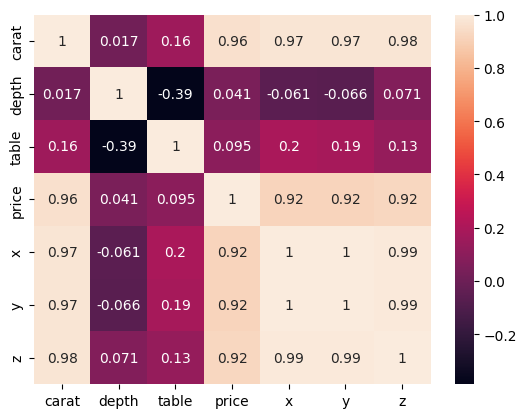

In [ ]:
sns.heatmap(nu.corr(),annot=True)

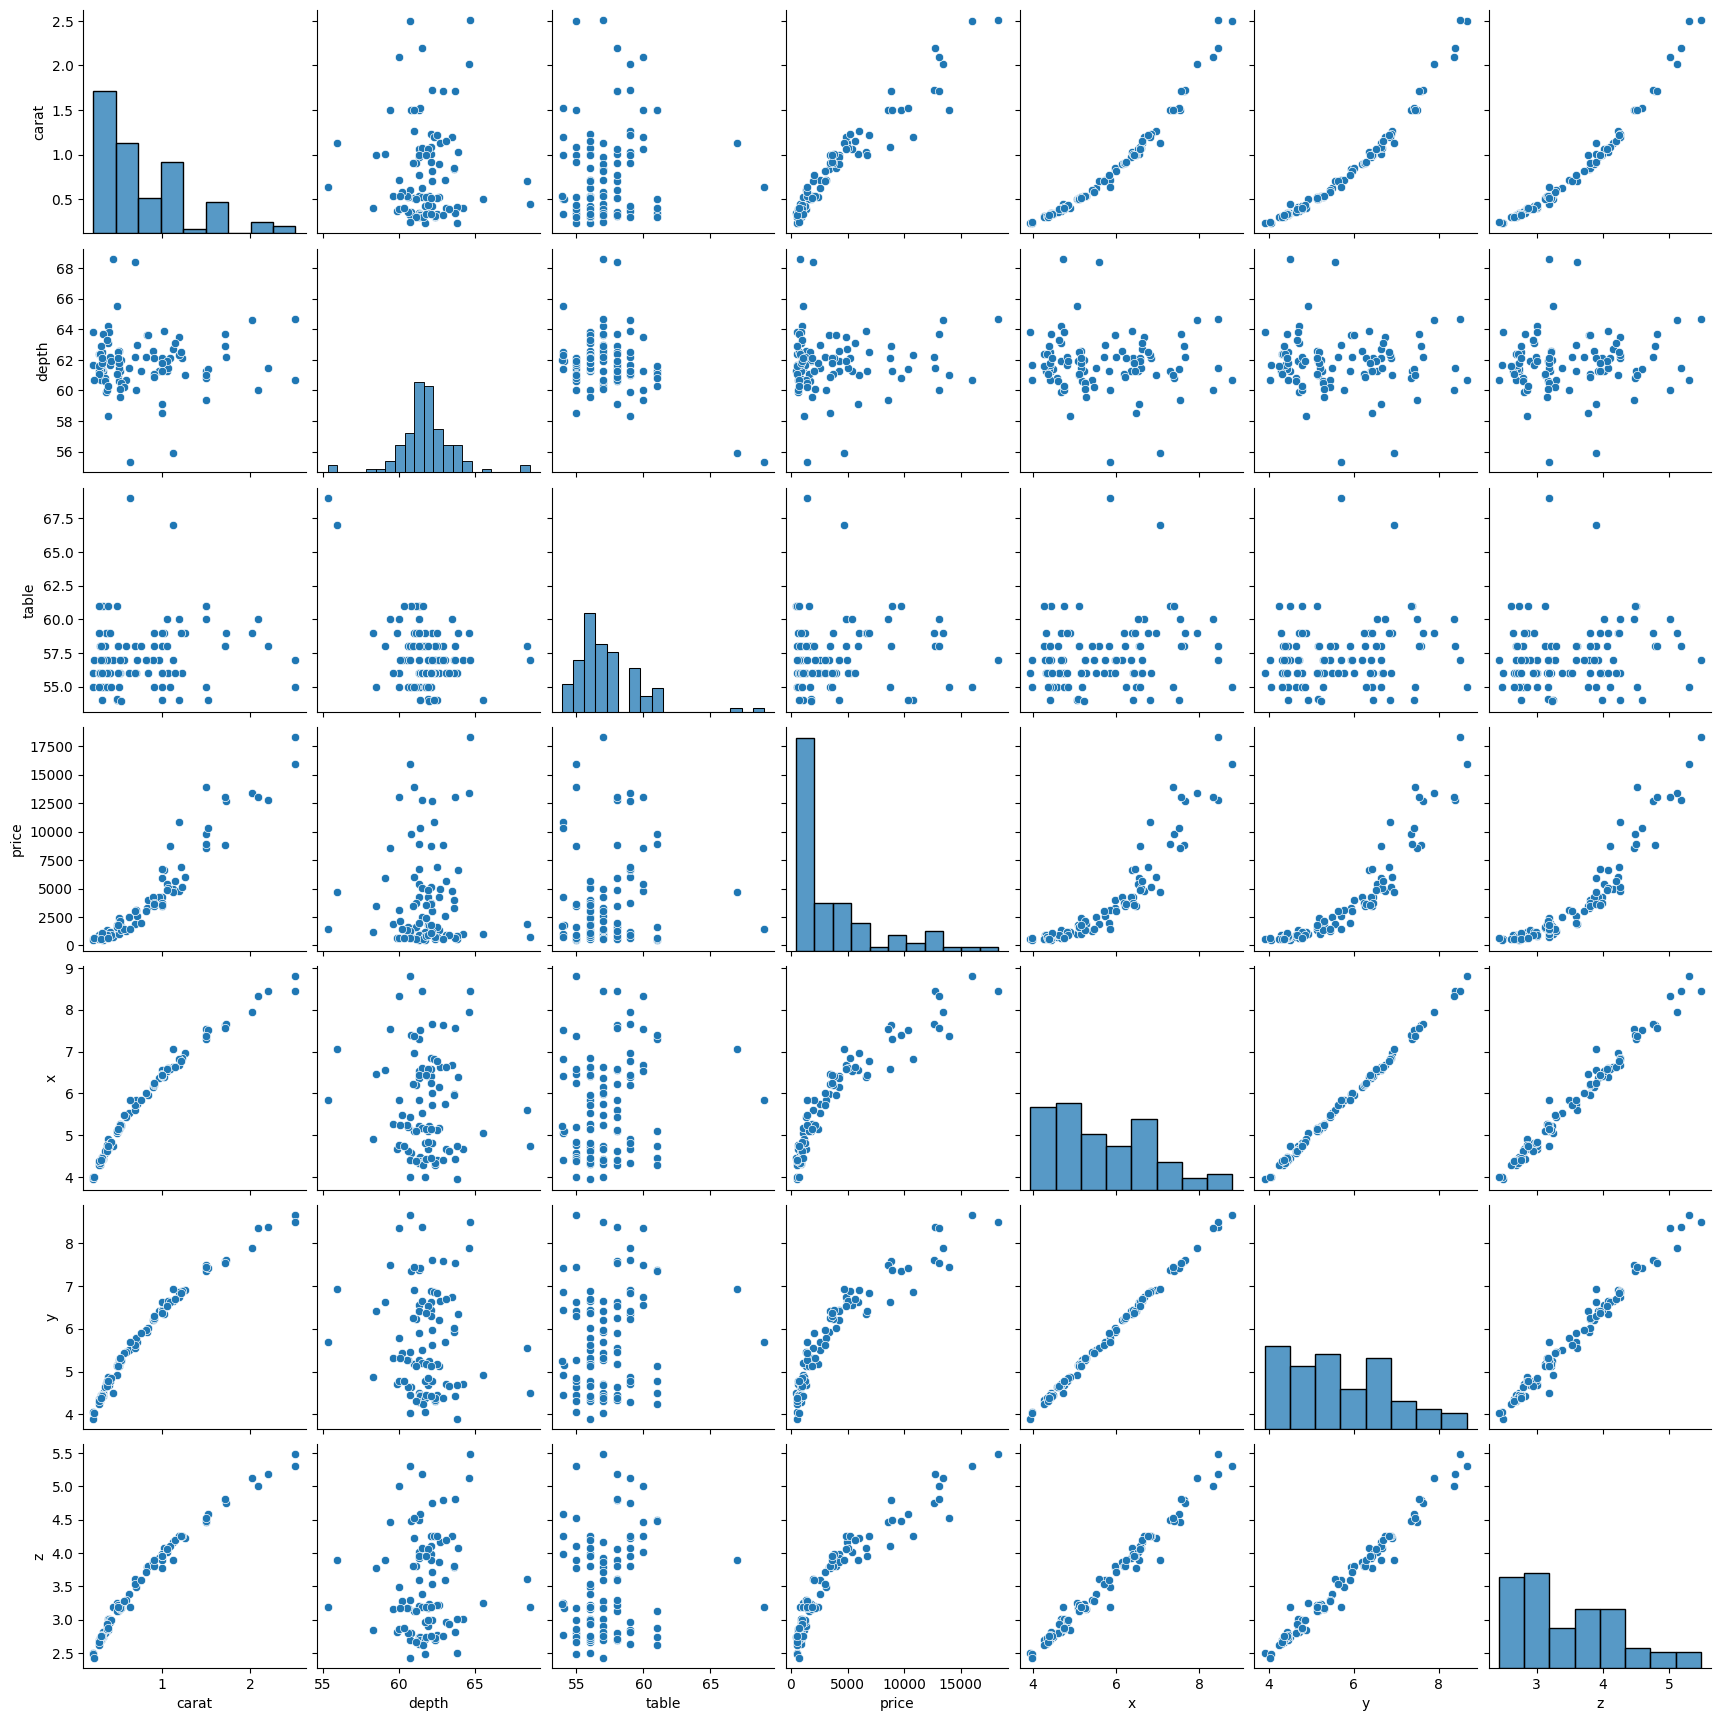

In [ ]:
sns.pairplot(nu)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, 7709 to 28364
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    100 non-null    float64 
 1   cut      100 non-null    category
 2   color    100 non-null    category
 3   clarity  100 non-null    category
 4   depth    100 non-null    float64 
 5   table    100 non-null    float64 
 6   price    100 non-null    int64   
 7   x        100 non-null    float64 
 8   y        100 non-null    float64 
 9   z        100 non-null    float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 7.5 KB


In [ ]:
df.describe()

,carat,depth,table,price,x,y,z
count,100.000000,100.0000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,0.781900,61.7800,57.230000,3703.890000,5.669800,5.670300,3.499500
std,0.519797,1.8212,2.398927,3999.752671,1.190345,1.185896,0.735941
min,0.230000,55.3000,53.900000,447.000000,3.940000,3.900000,2.430000
25%,0.390000,61.0000,56.000000,896.500000,4.677500,4.682500,2.857500
50%,0.540000,61.7500,57.000000,1858.000000,5.260000,5.310000,3.230000
75%,1.037500,62.5000,58.000000,4877.000000,6.537500,6.535000,3.995000
max,2.510000,68.6000,69.000000,18308.000000,8.800000,8.660000,5.480000


<Axes: >

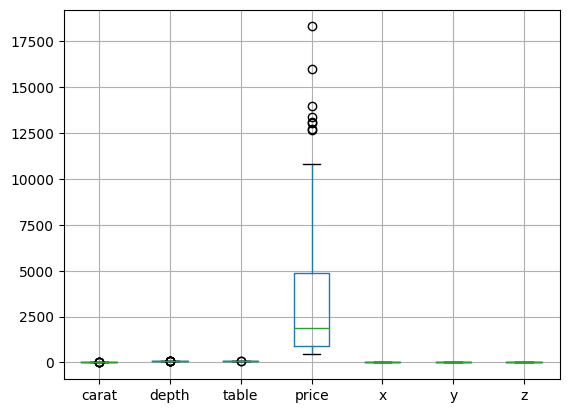

In [ ]:
df.boxplot()

<Axes: >

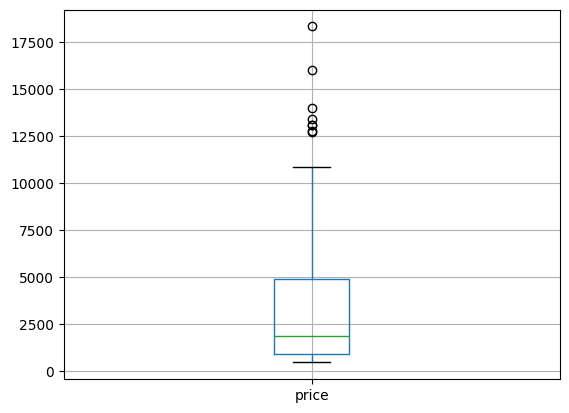

In [ ]:
df.boxplot("price")

In [ ]:
x=[1,2,3]
for i in x:
  print(i)

1
2
3


In [ ]:
nu=df.select_dtypes(include="number")
nu

,carat,depth,table,price,x,y,z
7709,1.00,61.9,54.0,4278,6.41,6.45,3.98
38507,0.50,65.5,54.0,1031,5.06,4.92,3.25
46350,0.50,61.9,54.1,1759,5.09,5.15,3.17
11073,1.13,62.7,57.0,4922,6.62,6.65,4.16
26447,2.50,60.7,55.0,15990,8.80,8.66,5.30
...,...,...,...,...,...,...,...
43398,0.64,55.3,69.0,1411,5.85,5.69,3.19
39151,0.33,62.1,56.0,1062,4.46,4.43,2.76
6058,0.32,62.9,57.0,576,4.40,4.37,2.76
47177,0.51,62.1,56.0,1836,5.15,5.13,3.19


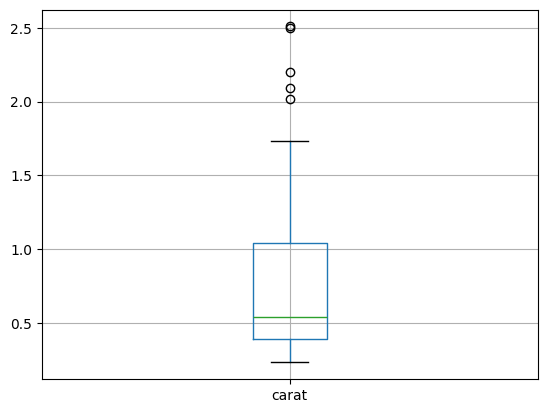

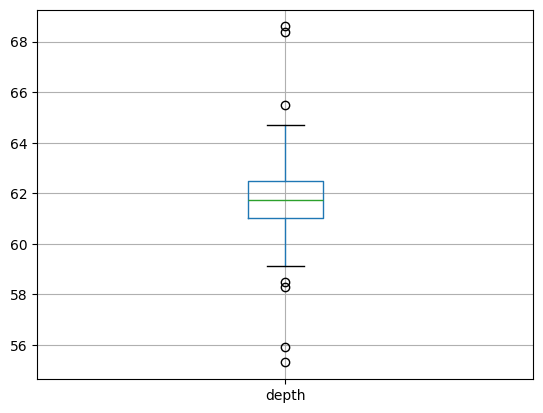

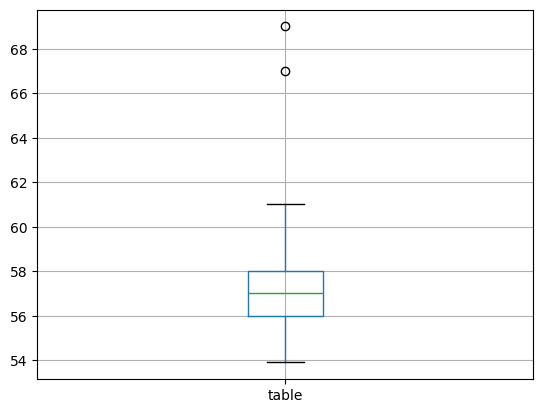

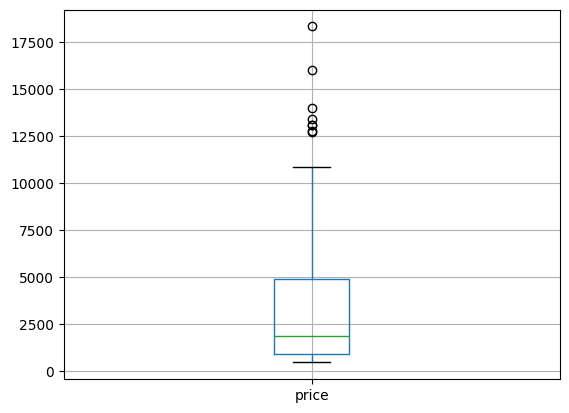

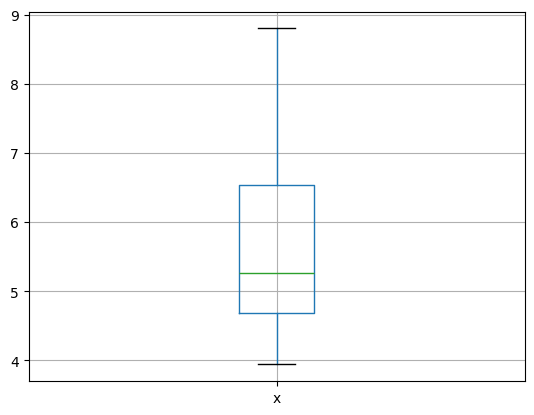

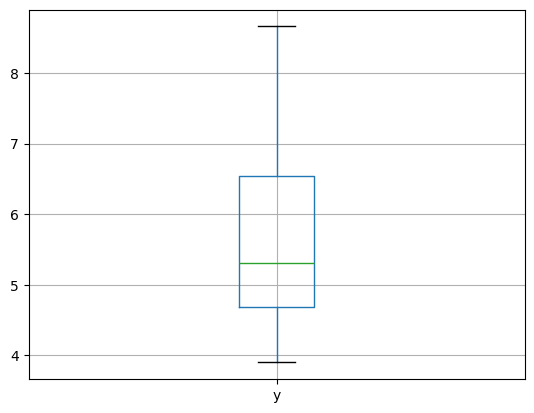

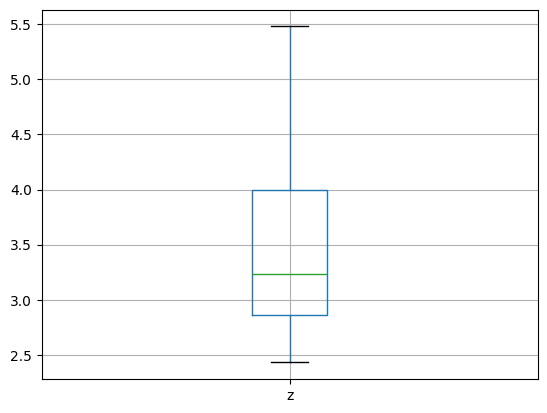

In [ ]:
import matplotlib.pyplot as plt

x=list(nu)
for i in x:
  df.boxplot(i)
  plt.show()

In [ ]:
df["color"].value_counts()

,count
color,
F,25
G,18
E,16
I,16
H,11
D,7
J,7


<Axes: xlabel='color', ylabel='count'>

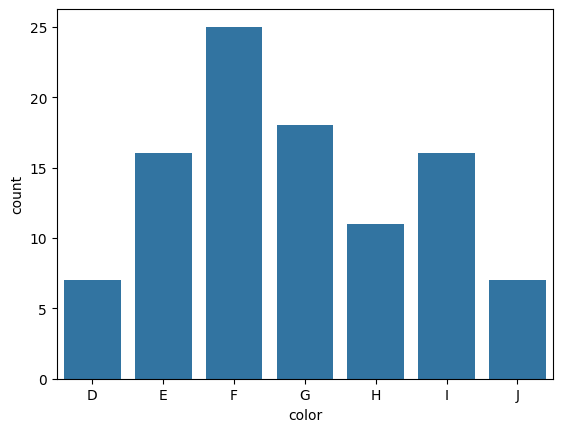

In [ ]:
sns.countplot(x=df["color"])

In [ ]:
df[df["price"]>2000]

,carat,cut,color,clarity,depth,table,price,x,y,z
7709,1.00,Ideal,J,VS2,61.9,54.0,4278,6.41,6.45,3.98
11073,1.13,Very Good,E,SI1,62.7,57.0,4922,6.62,6.65,4.16
26447,2.50,Ideal,J,SI2,60.7,55.0,15990,8.80,8.66,5.30
24478,2.20,Premium,H,SI2,61.5,58.0,12747,8.44,8.38,5.18
20515,1.71,Premium,J,SI1,62.9,58.0,8848,7.64,7.58,4.79
24422,1.73,Premium,I,VS1,62.2,59.0,12674,7.65,7.62,4.75
10613,1.20,Good,G,SI1,63.5,60.0,4828,6.68,6.74,4.26
52786,0.72,Premium,D,SI1,63.0,57.0,2567,5.74,5.69,3.60
3088,0.84,Good,G,VS1,63.6,57.0,3316,5.98,5.93,3.79
48741,0.53,Ideal,G,VVS1,61.3,56.0,2015,5.22,5.26,3.21


In [ ]:
df["price"].count() #aggregate function

np.int64(100)

In [ ]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [ ]:
# Data preprocessing
# Convert categorical columns to numerical using one-hot encoding
df = pd.get_dummies(df,drop_first=True,dtype="int")

df

NameError: name 'pd' is not defined

In [ ]:
# Features and target
X = df.drop('price', axis=1)
y = df['price']

# **Feature Selection in Machine Learning**
Feature selection helps improve model performance by removing irrelevant or redundant features.

### **Feature Selection Using Feature Importance**
Feature importance methods help identify the most useful features. These are commonly used with tree-based models.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor() #GENERAL
model.fit(X, y)
feature_importance = pd.Series(model.feature_importances_, index=X.columns)
print(feature_importance.sort_values(ascending=False))


z                4.485904e-01
x                1.823576e-01
carat            1.654108e-01
y                1.650830e-01
table            1.182643e-02
clarity_SI1      5.031821e-03
depth            4.279522e-03
clarity_VVS2     2.855221e-03
clarity_VVS1     2.624036e-03
color_F          2.235469e-03
cut_Premium      1.624686e-03
clarity_SI2      1.156025e-03
color_I          1.094808e-03
clarity_VS2      1.004063e-03
color_E          9.613402e-04
cut_Fair         8.251463e-04
color_G          7.509930e-04
color_J          5.771774e-04
cut_Very Good    5.403648e-04
color_H          5.158318e-04
clarity_VS1      4.424996e-04
cut_Good         2.123300e-04
clarity_I1       3.549583e-07
dtype: float64


In [ ]:
# Keep features with importance > 0.01
selected_features = feature_importance[feature_importance > 0.01].index
X_selected = X[selected_features]

print("Selected Features:", selected_features)


Selected Features: Index(['carat', 'table', 'x', 'y', 'z'], dtype='object')


In [ ]:


from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X_selected)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error

# Initialize an empty list to store results
results = []

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predictions on test data
lr_pred = lr_model.predict(X_test)

# Calculate Mean Squared Error and R² Score for testing data
lr_mse = mean_squared_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)
lr_mae=mean_absolute_error(y_test,lr_pred)

# Predictions on training data
y_train_pred = lr_model.predict(X_train)

# Calculate R² Score for training data
train_r2 = r2_score(y_train, y_train_pred)

# Append results to the list
results.append({
    'Model': 'Linear Regression',
    'Mean Squared Error': lr_mse,
    'R2 Score (Test)': lr_r2,
    'R2 Score (Train)': train_r2
})

# Print results
print(results)


[{'Model': 'Linear Regression', 'Mean Squared Error': 1623239.0087005426, 'R2 Score (Test)': 0.9415461997033843, 'R2 Score (Train)': 0.9265778952191699}]


In [ ]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

# Fit SVR model
svr_model = SVR()
svr_model.fit(X_train, y_train)

# Predictions on test data
svr_pred = svr_model.predict(X_test)

# Calculate Mean Squared Error and R² Score for testing data
svr_mse = mean_squared_error(y_test, svr_pred)
svr_r2 = r2_score(y_test, svr_pred)

# Predictions on training data
y_train_pred = svr_model.predict(X_train)

# Calculate R² Score for training data
train_r2 = r2_score(y_train, y_train_pred)

# Store results
results.append({
    'Model': 'Support Vector Regression',
    'Mean Squared Error': svr_mse,
    'R2 Score (Test)': svr_r2,
    'R2 Score (Train)': train_r2
})

print(results)


[{'Model': 'Linear Regression', 'Mean Squared Error': 1623239.0087005426, 'R2 Score (Test)': 0.9415461997033843, 'R2 Score (Train)': 0.9265778952191699}, {'Model': 'Support Vector Regression', 'Mean Squared Error': 37183299.55772112, 'R2 Score (Test)': -0.338992689965129, 'R2 Score (Train)': -0.21417025527372724}]


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score



# Gradient Boosting
gb_model = GradientBoostingRegressor()
gb_model.fit(X_train, y_train)

# Predictions on test data
gb_pred = gb_model.predict(X_test)

# Calculate Mean Squared Error and R² Score for testing data
gb_mse = mean_squared_error(y_test, gb_pred)
gb_r2 = r2_score(y_test, gb_pred)

# Predictions on training data
y_train_pred = gb_model.predict(X_train)

# Calculate R² Score for training data
train_r2 = r2_score(y_train, y_train_pred)

# Append results to the list
results.append({
    'Model': 'Gradient Boosting',
    'Mean Squared Error': gb_mse,
    'R2 Score (Test)': gb_r2,
    'R2 Score (Train)': train_r2
})

# Print results
print(results)


[{'Model': 'Linear Regression', 'Mean Squared Error': 1623239.0087005426, 'R2 Score (Test)': 0.9415461997033843, 'R2 Score (Train)': 0.9265778952191699}, {'Model': 'Support Vector Regression', 'Mean Squared Error': 37183299.55772112, 'R2 Score (Test)': -0.338992689965129, 'R2 Score (Train)': -0.21417025527372724}, {'Model': 'Gradient Boosting', 'Mean Squared Error': 3245336.973381133, 'R2 Score (Test)': 0.883133489079278, 'R2 Score (Train)': 0.9985602869205873}]


In [ ]:
from sklearn.ensemble import RandomForestcLASSIFERI
from sklearn.metrics import mean_squared_error, r2_score


# Random Forest
rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)

# Predictions on test data
rf_pred = rf_model.predict(X_test)

# Calculate Mean Squared Error and R² Score for testing data
rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

# Predictions on training data
y_train_pred = rf_model.predict(X_train)

# Calculate R² Score for training data
train_r2 = r2_score(y_train, y_train_pred)

# Append results to the list
results.append({
    'Model': 'Random Forest',
    'Mean Squared Error': rf_mse,
    'R2 Score (Test)': rf_r2,
    'R2 Score (Train)': train_r2
})

# Print results
print(results)


[{'Model': 'Linear Regression', 'Mean Squared Error': 1623239.0087005426, 'R2 Score (Test)': 0.9415461997033843, 'R2 Score (Train)': 0.9265778952191699}, {'Model': 'Support Vector Regression', 'Mean Squared Error': 37183299.55772112, 'R2 Score (Test)': -0.338992689965129, 'R2 Score (Train)': -0.21417025527372724}, {'Model': 'Gradient Boosting', 'Mean Squared Error': 3245336.973381133, 'R2 Score (Test)': 0.883133489079278, 'R2 Score (Train)': 0.9985602869205873}, {'Model': 'Random Forest', 'Mean Squared Error': 3183146.63375, 'R2 Score (Test)': 0.8853730001270609, 'R2 Score (Train)': 0.9832684155732577}]


In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score


# Decision Tree
dt_model = DecisionTreeRegressor()
dt_model.fit(X_train, y_train)

# Predictions on test data
dt_pred = dt_model.predict(X_test)

# Calculate Mean Squared Error and R² Score for testing data
dt_mse = mean_squared_error(y_test, dt_pred)
dt_r2 = r2_score(y_test, dt_pred)

# Predictions on training data
y_train_pred = dt_model.predict(X_train)

# Calculate R² Score for training data
train_r2 = r2_score(y_train, y_train_pred)

# Append results to the list
results.append({
    'Model': 'Decision Tree',
    'Mean Squared Error': dt_mse,
    'R2 Score (Test)': dt_r2,
    'R2 Score (Train)': train_r2
})

# Print results
print(results)


[{'Model': 'Linear Regression', 'Mean Squared Error': 1623239.0087005426, 'R2 Score (Test)': 0.9415461997033843, 'R2 Score (Train)': 0.9265778952191699}, {'Model': 'Support Vector Regression', 'Mean Squared Error': 37183299.55772112, 'R2 Score (Test)': -0.338992689965129, 'R2 Score (Train)': -0.21417025527372724}, {'Model': 'Gradient Boosting', 'Mean Squared Error': 3245336.973381133, 'R2 Score (Test)': 0.883133489079278, 'R2 Score (Train)': 0.9985602869205873}, {'Model': 'Random Forest', 'Mean Squared Error': 3183146.63375, 'R2 Score (Test)': 0.8853730001270609, 'R2 Score (Train)': 0.9832684155732577}, {'Model': 'Decision Tree', 'Mean Squared Error': 3676535.05, 'R2 Score (Test)': 0.8676057903707917, 'R2 Score (Train)': 1.0}]


In [ ]:

# Create a DataFrame to display the results
results_df = pd.DataFrame(results)
results_df
# Display the results

,Model,Mean Squared Error,R2 Score (Test),R2 Score (Train)
0,Linear Regression,1.623239e+06,0.941546,0.926578
1,Support Vector Regression,3.718330e+07,-0.338993,-0.214170
2,Gradient Boosting,3.245337e+06,0.883133,0.998560
3,Random Forest,3.183147e+06,0.885373,0.983268
4,Decision Tree,3.676535e+06,0.867606,1.000000


# **hyper parameter tuning**

In [ ]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid_svr = {
    'C': [0.1, 1, 10,100],
    'kernel': ['linear', 'rbf',"poly"],
    'gamma': ['scale', 'auto']
}

# Initialize the SVR model
svr = SVR()

# Perform GridSearchCV with R² scoring
grid_search_svr = GridSearchCV(estimator=svr, param_grid=param_grid_svr, cv=5, scoring='r2')
grid_search_svr.fit(X_train, y_train)

# Print the best parameters and score
print(f"Best parameters for SVR: {grid_search_svr.best_params_}")
print(f"Best R² score for SVR: {grid_search_svr.best_score_}")


Best parameters for SVR: {'C': 100, 'gamma': 'scale', 'kernel': 'linear'}
Best R² score for SVR: 0.7797969032327156


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

# Define the model
gb = GradientBoostingRegressor(random_state=42)

# Define the parameter grid
param_grid_gb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

# Perform GridSearchCV
grid_search_gb = GridSearchCV(estimator=gb, param_grid=param_grid_gb, cv=5, scoring='r2', n_jobs=-1)
grid_search_gb.fit(X_train, y_train)

# Print best parameters and score
print(f"Best parameters for Gradient Boosting: {grid_search_gb.best_params_}")
print(f"Best R² score for Gradient Boosting: {grid_search_gb.best_score_}")


Best parameters for Gradient Boosting: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
Best R² score for Gradient Boosting: 0.8374608867386872


In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

# Define the model
dt = DecisionTreeRegressor(random_state=42)

# Define the parameter grid
param_grid_dt = {
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Perform GridSearchCV
grid_search_dt = GridSearchCV(estimator=dt, param_grid=param_grid_dt, cv=5, scoring='r2', n_jobs=-1)
grid_search_dt.fit(X_train, y_train)

# Print best parameters and score
print(f"Best parameters for Decision Tree: {grid_search_dt.best_params_}")
print(f"Best R² score for Decision Tree: {grid_search_dt.best_score_}")


Best parameters for Decision Tree: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best R² score for Decision Tree: 0.7784858995654316


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Define the model
rf = RandomForestRegressor(random_state=42)

# Define the parameter grid
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, None],
    'max_features': ['sqrt', 'log2'],
    'min_samples_split': [2, 5, 10]
}

# Perform GridSearchCV
grid_search_rf = GridSearchCV(estimator=rf, param_grid=param_grid_rf, cv=5, scoring='r2', n_jobs=-1)
grid_search_rf.fit(X_train, y_train)

# Print best parameters and score
print(f"Best parameters for Random Forest: {grid_search_rf.best_params_}")
print(f"Best R² score for Random Forest: {grid_search_rf.best_score_}")


Best parameters for Random Forest: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 100}
Best R² score for Random Forest: 0.882966631509095


# reasons for over fitting
1. if no of features are too high - overfit- l1 reg(lasso)
2. multicolliniarity- feature drop, l2 reg(ridge)
3. number of classes are too high